# EDA project of Medicare dataset

## Introduction

The project is solely based on learning purpose and to showcase the skills and experties with handling and getting insights from data. For this project I used the Medicare Part D Prescribers.

Link: https://catalog.data.gov/dataset/medicare-part-d-prescribers-by-provider-and-drug-ad73e

### Dataset descripton and license

The Medicare Part D Prescribers by Provider and Drug dataset provides information on prescription drugs prescribed to Medicare beneficiaries enrolled in Part D by physicians and other health care providers. This dataset contains the total number of prescription fills that were dispensed and the total drug cost paid organized by prescribing National Provider Identifier (NPI), drug brand name (if applicable) and drug generic name.


license: https://www.usa.gov/government-copyright#:~:text=On%20federal%20websites%2C%20other%20people%20may%20have%20rights%20to%20the%20work%20itself%20or%20how%20people%20use%20it.%20This%20includes%20publicity%20or%20privacy%20rights%20under%20state%20law.%20These%20rights%20protect%20the%20interests%20of%20the%20person%20or%20people%20who%20may%20be%20the%20subject%20of%20the%20work.%C2%A0


## Objective 

First I look at the dataset that how many columns and rows are there and what are the datatypes and what and how can i get insights.

objectives would be clear overtime now we don't know the data so we should go with broad objective in mind



### Importing libraries

We would need libraries to store, manipulate and visualize the data. For that i would be using following libraries

* Pandas for data-storage and manipulation
* Numpy for mathematical operation
* Seaborn and pyplot for data visualization

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Loading dataset 

In [2]:
import os

# 1. Setup paths
data_dir = "Datasets"
csv_file = os.path.join(data_dir, "MUP_DPR_RY25_P04_V10_DY23_NPIBN.csv")


df = pd.read_csv(csv_file) 

# df = pd.read_csv(csv_file, dtype={'Prscrbr_State_FIPS': str}) # best practice to specify dtype for columns that may have leading zeros or are categorical in nature.


C:\Users\HP\AppData\Local\Temp\ipykernel_11036\3242835374.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


in loading file we had datatype warning on column number 5. To solve that we need to have information about dataset

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26794878 entries, 0 to 26794877
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Prscrbr_NPI            int64  
 1   Prscrbr_Last_Org_Name  object 
 2   Prscrbr_First_Name     object 
 3   Prscrbr_City           object 
 4   Prscrbr_State_Abrvtn   object 
 5   Prscrbr_State_FIPS     object 
 6   Prscrbr_Type           object 
 7   Prscrbr_Type_Src       object 
 8   Brnd_Name              object 
 9   Gnrc_Name              object 
 10  Tot_Clms               int64  
 11  Tot_30day_Fills        float64
 12  Tot_Day_Suply          int64  
 13  Tot_Drug_Cst           float64
 14  Tot_Benes              float64
 15  GE65_Sprsn_Flag        object 
 16  GE65_Tot_Clms          float64
 17  GE65_Tot_30day_Fills   float64
 18  GE65_Tot_Drug_Cst      float64
 19  GE65_Tot_Day_Suply     float64
 20  GE65_Bene_Sprsn_Flag   object 
 21  GE65_Tot_Benes         float64
dtypes: float64(8), i

specifying column 5 (Prscrbr_State_FIPS) datatype as string/object instead of integer

In [4]:
df['Prscrbr_State_FIPS'] = df['Prscrbr_State_FIPS'].astype(str)

Checking that the column 5 datatype is correctly assign

In [5]:
col5_dtype = df['Prscrbr_State_FIPS'].dtype 
col5_uvalues = df['Prscrbr_State_FIPS'].unique()[:10] 
col5_null_count = df['Prscrbr_State_FIPS'].isnull().sum()

col5_dtype, col5_uvalues, col5_null_count

(dtype('O'),
 array(['24', '39', '32', '8', '42', '40', '12', '48', '35', '21'],
       dtype=object),
 np.int64(0))

### Data cleaning, data integrity checks

Before we move to assigning ourself an objective of this project we need to clean and validate the data.

For that we need few things 

* Check null values 
* Check duplicates

This step is crucial for analysis 

In [6]:
df.isnull().sum()

Prscrbr_NPI                     0
Prscrbr_Last_Org_Name           0
Prscrbr_First_Name              9
Prscrbr_City                    1
Prscrbr_State_Abrvtn            0
Prscrbr_State_FIPS              0
Prscrbr_Type                    2
Prscrbr_Type_Src                0
Brnd_Name                       0
Gnrc_Name                       0
Tot_Clms                        0
Tot_30day_Fills                 0
Tot_Day_Suply                   0
Tot_Drug_Cst                    0
Tot_Benes                14757509
GE65_Sprsn_Flag          14724059
GE65_Tot_Clms            12070819
GE65_Tot_30day_Fills     12070819
GE65_Tot_Drug_Cst        12070819
GE65_Tot_Day_Suply       12070819
GE65_Bene_Sprsn_Flag      3094106
GE65_Tot_Benes           23700772
dtype: int64

Since the data is around 26 million rows big the null values is insignificant. due to following reason

* Prscrbr_First_Name, Prscrbr_City, Prscrbr_Type had ~ less than 1% null values
* Tot_Benes = total beneficiaries mean that around 14 million rows have no beneficiaries
* GE65 means people of age 65 or older obviously not all population is old so their should be empty cells null values

In [7]:
df.duplicated().sum()

np.int64(0)

### Data Quality
After conducting a thorough audit for **null values** and **duplicate records**, we can confidently state that the dataset is clean and ready for analysis. 

> **Note:** While columns like `Prscrbr_NPI` and `Gnrc_Name` show high counts of duplicate values, these represent valid many-to-many relationships between healthcare providers and the medications they prescribe, rather than data entry errors.

---

### Data Dictionary
Below is a definition of the 22 columns included in this dataset, standardized according to federal reporting guidelines.

| # | Column Name | Data Type | Description |
| :--- | :--- | :--- | :--- |
| 0 | **Prscrbr_NPI** | `int64` | National Provider Identifier (Unique 10-digit ID). |
| 1 | **Prscrbr_Last_Org_Name** | `object` | Last name or Organization name of the prescriber. |
| 2 | **Prscrbr_First_Name** | `object` | First name of the prescriber. |
| 3 | **Prscrbr_City** | `object` | City where the prescriber is located. |
| 4 | **Prscrbr_State_Abrvtn** | `object` | Two-letter state abbreviation. |
| 5 | **Prscrbr_State_FIPS** | `object` | Federal Information Processing Series numerical code. |
| 6 | **Prscrbr_Type** | `object` | The prescriber’s clinical specialty. |
| 7 | **Prscrbr_Type_Src** | `object` | Source of the prescriber specialty information. |
| 8 | **Brnd_Name** | `object` | The proprietary (Brand) name of the medication. |
| 9 | **Gnrc_Name** | `object` | The chemical (Generic) name of the medication. |
| 10 | **Tot_Clms** | `int64` | Total number of prescriptions filled (including refills). |
| 11 | **Tot_30day_Fills** | `float64` | Number of fills standardized to a 30-day supply. |
| 12 | **Tot_Day_Suply** | `int64` | Total number of days' supply for all claims. |
| 13 | **Tot_Drug_Cst** | `float64` | Total cost paid for the drugs (USD). |
| 14 | **Tot_Benes** | `float64` | Total unique beneficiaries receiving the drug. |
| 15 | **GE65_Sprsn_Flag** | `object` | Privacy suppression flag for patients $\ge$ 65. |
| 16 | **GE65_Tot_Clms** | `float64` | Total claims for patients aged 65+. |
| 17 | **GE65_Tot_30day_Fills** | `float64` | 30-day standardized fills for patients 65+. |
| 18 | **GE65_Tot_Drug_Cst** | `float64` | Total drug cost for patients 65+. |
| 19 | **GE65_Tot_Day_Suply** | `float64` | Total day supply for patients 65+. |
| 20 | **GE65_Bene_Sprsn_Flag** | `object` | Privacy suppression flag for beneficiary counts. |
| 21 | **GE65_Tot_Benes** | `float64` | Total unique beneficiaries aged 65+. |

---

### Validating Gnrc and brnd

Checking if there is misspelling in generic or brand names. I need real dataset from FDA which is publically available

Link: https://www.fda.gov/drugs/drug-approvals-and-databases/drugsfda-data-files?utm_source=chatgpt.com 

Products.txt --> Choose this file for referencing.

If you want you can use other sources like RxNorm, DrugBank, etc.

> **Note:** For RxNorm dataset you would eequire a UMLS license.

### Loading FDA Dataset

In [8]:
data_dir = "Datasets"
csv_file_2 = os.path.join(data_dir, "Products.txt")

fda = pd.read_csv(csv_file_2, sep="\t", encoding="latin1")

Checking datatype and columns of FDA drug list

In [9]:
fda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50899 entries, 0 to 50898
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplNo             50899 non-null  int64  
 1   ProductNo          50899 non-null  int64  
 2   Form               50899 non-null  object 
 3   Strength           50723 non-null  object 
 4   ReferenceDrug      50899 non-null  int64  
 5   DrugName           50899 non-null  object 
 6   ActiveIngredient   50899 non-null  object 
 7   ReferenceStandard  49592 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 3.1+ MB


Looking at 1st 10 rows of data to understand the formatting of FDA drug list

In [10]:
fda.head(10)

,ApplNo,ProductNo,Form,Strength,ReferenceDrug,DrugName,ActiveIngredient,ReferenceStandard
0,4,4,SOLUTION/DROPS;OPHTHALMIC,1%,0,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,0.0
1,159,1,TABLET;ORAL,500MG,0,SULFAPYRIDINE,SULFAPYRIDINE,0.0
2,552,1,INJECTABLE;INJECTION,"20,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0.0
3,552,2,INJECTABLE;INJECTION,"40,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0.0
4,552,3,INJECTABLE;INJECTION,"5,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0.0
5,552,4,INJECTABLE;INJECTION,"1,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0.0
6,552,5,INJECTABLE;INJECTION,"10,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0.0
7,552,7,INJECTABLE;INJECTION,100 UNITS/ML,0,LIQUAEMIN LOCK FLUSH,HEPARIN SODIUM,0.0
8,552,8,INJECTABLE;INJECTION,"1,000 UNITS/ML",0,HEPARIN SODIUM,HEPARIN SODIUM,0.0
9,552,9,INJECTABLE;INJECTION,"5,000 UNITS/ML",0,HEPARIN SODIUM,HEPARIN SODIUM,0.0


Cleaning and arrangung data in a useful form for generic and brand names

In [11]:
brand_names = (
    fda['DrugName']
    .dropna() # Drop missing values to avoid issues with string operations
    .str.lower() # Convert to lowercase for uniformity
    .str.strip() # Remove leading/trailing whitespace
    .drop_duplicates() # Remove duplicate brand names
)

generic_names = (
    fda['ActiveIngredient']
    .dropna()
    .str.lower()
    .str.strip()
    .drop_duplicates()
)

Converting it to sets for fast hash-lookups

In [12]:
brand_set = set(brand_names)
generic_set = set(generic_names)

Arranging the Generics and Brands as we did with FDA dataset

In [13]:
df['Gnrc_Name'] = df['Gnrc_Name'].str.lower().str.strip()
df['Brnd_Name'] = df['Brnd_Name'].str.lower().str.strip()

Now we can place our logic for spelling errors 

In [14]:
unknown_generics = df[~df['Gnrc_Name'].isin(generic_set)] # ~ is the negation operator, it selects rows where the condition is False
unknown_brands = df[~df['Brnd_Name'].isin(brand_set)] 


### Importing rapidfuzz

`pip install rapidfuzz`

It would be helpful for misspell correction.

Check is it working nicely

In [15]:
from rapidfuzz import process

def suggest_drug(name, reference):
    match = process.extractOne(name, reference)
    return match

suggest_drug("metmorpin", generic_set)

('dapagliflozin; metformin hydrochloride', 70.00000000000001, 103)

### Saving Into csv

Its nice to have saved files of what we did to format fda drug list

In [16]:
brand_names.to_csv("reference_brand_names.csv", index=False)
generic_names.to_csv("reference_generic_names.csv", index=False)  

Looking at the generic from FDA drug list we can have multiple drugs in ActiveIngredients which we used for generics so to sort this problem we simply split the activesingredients 

In [17]:
ingredients = (
    fda['ActiveIngredient']
    .str.lower()
    .str.split(';')
    .explode()
    .str.strip()
    .drop_duplicates()
)

Now we merge brand and generic names from fda drug list to our original dataset for accuracy

In [19]:
fda['DrugName'] = fda['DrugName'].str.lower().str.strip()
fda['ActiveIngredient'] = fda['ActiveIngredient'].str.lower().str.strip()

df['Brnd_Name'] = df['Brnd_Name'].str.lower().str.strip()

In [20]:
brand_lookup = (
    fda[['DrugName', 'ActiveIngredient']]
    .dropna()
    .drop_duplicates()
    .groupby('DrugName', as_index=False)
    .agg({'ActiveIngredient': 'first'})
)

This will help to find generic of brands

In [21]:
brand_lookup_dict = (
    fda[['DrugName', 'ActiveIngredient']]
    .dropna()
    .drop_duplicates()
    .groupby('DrugName')['ActiveIngredient']
    .first()
    .to_dict()
)

df['Mapped_Generic'] = df['Brnd_Name'].map(brand_lookup_dict)

Top 10 Generics by their Total claims i.e number of drugs sold

In [25]:
top10_generic = (
    df.groupby('Gnrc_Name')['Tot_Clms']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10_generic

Gnrc_Name
atorvastatin calcium    67633912
amlodipine besylate     46601898
levothyroxine sodium    45138029
lisinopril              35257305
gabapentin              33913654
losartan potassium      32407536
metformin hcl           31793565
metoprolol succinate    28792402
omeprazole              27230410
rosuvastatin calcium    25188902
Name: Tot_Clms, dtype: int64

<Axes: title={'center': 'Top 10 Generic Drugs by Total Claims'}, ylabel='Gnrc_Name'>

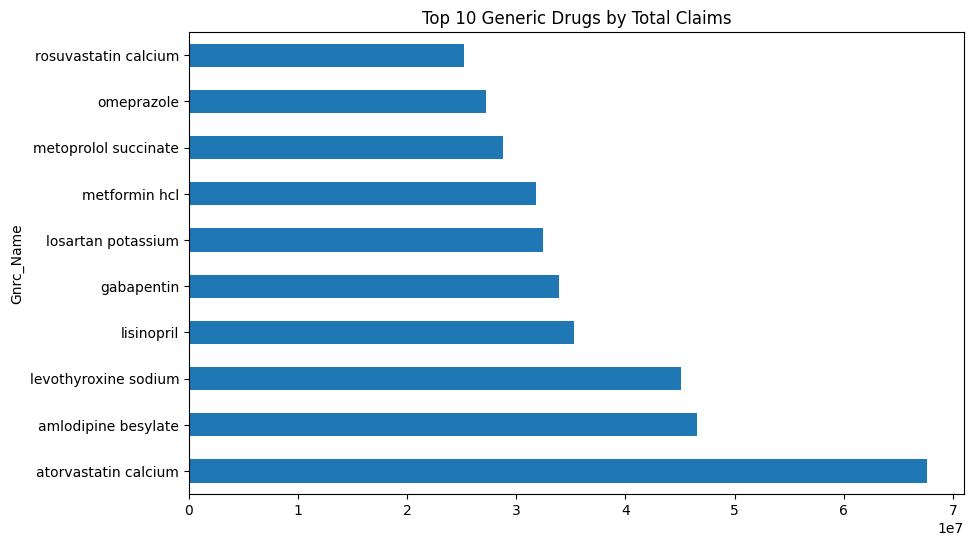

In [35]:
top10_generic.plot(kind='barh', figsize=(10,6), title="Top 10 Generic Drugs by Total Claims")

In [67]:
top10_generic_revenue = (
    df.groupby('Gnrc_Name')['Tot_Drug_Cst']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10_generic_revenue

Gnrc_Name
apixaban                          1.739216e+10
semaglutide                       9.670619e+09
empagliflozin                     8.031744e+09
dulaglutide                       6.666365e+09
rivaroxaban                       5.511694e+09
adalimumab                        4.884226e+09
lenalidomide                      4.816490e+09
insulin glargine,hum.rec.anlog    4.310702e+09
fluticasone/umeclidin/vilanter    4.011731e+09
dapagliflozin propanediol         3.719615e+09
Name: Tot_Drug_Cst, dtype: float64

<Axes: title={'center': 'Top 10 Generic Drugs by Total Revenue'}, ylabel='Gnrc_Name'>

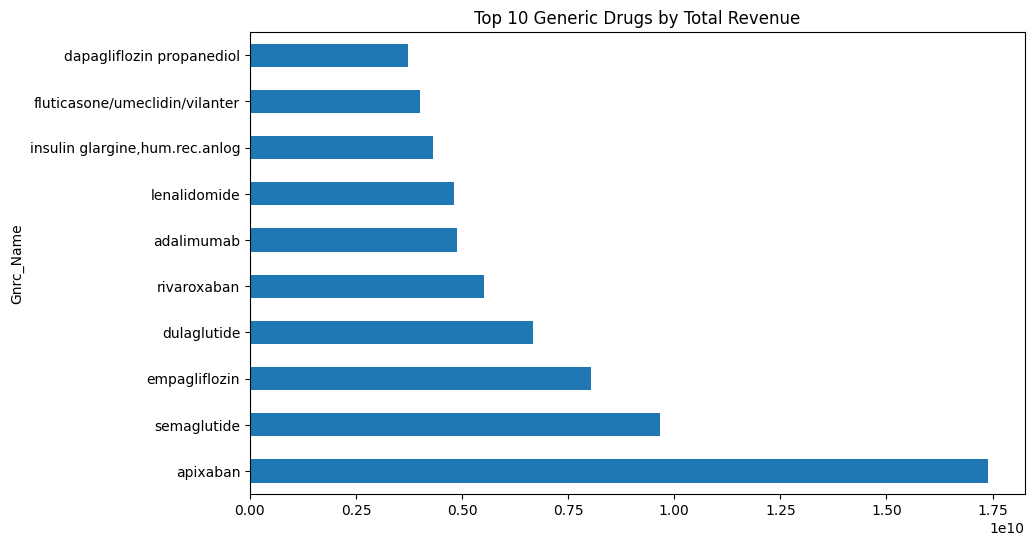

In [68]:
top10_generic_revenue.plot(kind='barh', figsize=(10,6), title="Top 10 Generic Drugs by Total Revenue")

In [23]:
top_brand = (
    df.groupby('Brnd_Name')['Tot_Clms']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_brand

Brnd_Name
atorvastatin calcium    67628906
amlodipine besylate     46596474
levothyroxine sodium    40911797
lisinopril              35256376
gabapentin              33898638
losartan potassium      32404784
metoprolol succinate    28768070
omeprazole              27230410
rosuvastatin calcium    25173567
metformin hcl           23197926
Name: Tot_Clms, dtype: int64

We can see that the drugs in both are same but the numbering is not exact



<Axes: title={'center': 'Top 10 Generic Drugs by Total Claims'}, ylabel='Brnd_Name'>

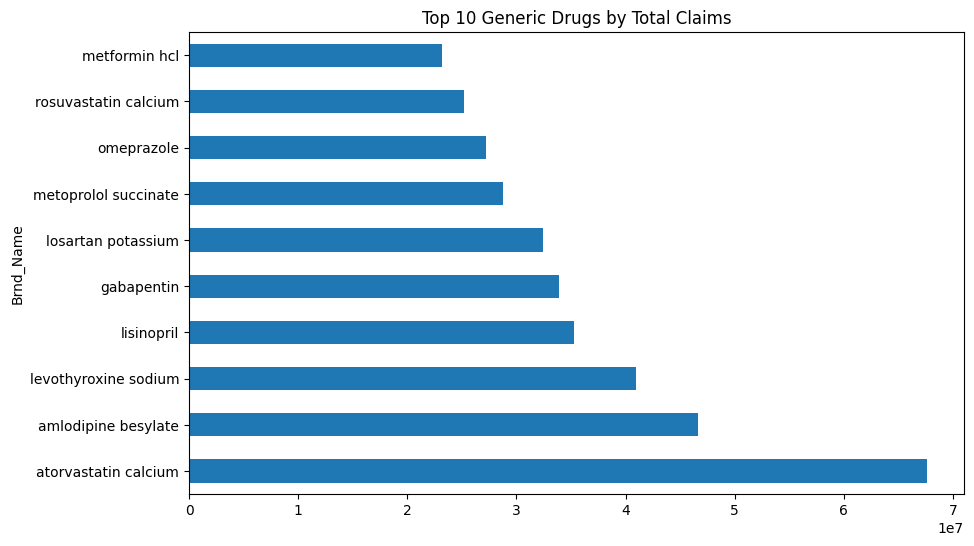

In [36]:
top_brand.plot(kind='barh', figsize=(10,6), title="Top 10 Generic Drugs by Total Claims")

lets do generic stratification into brands

In [37]:
stratified_df = df[df['Gnrc_Name'].isin(top10_generic.index)]

stratified_df = stratified_df.groupby(['Gnrc_Name', 'Brnd_Name'])['Tot_Clms'].sum().reset_index()

stratified_df = stratified_df.sort_values(by=['Gnrc_Name', 'Tot_Clms'], ascending=[True, False])

In [39]:
stratified_df

,Gnrc_Name,Brnd_Name,Tot_Clms
0,amlodipine besylate,amlodipine besylate,46596474
2,amlodipine besylate,norvasc,5361
1,amlodipine besylate,norliqva,63
3,atorvastatin calcium,atorvastatin calcium,67628906
4,atorvastatin calcium,lipitor,5006
5,gabapentin,gabapentin,33898638
6,gabapentin,gralise,10505
7,gabapentin,neurontin,4511
10,levothyroxine sodium,levothyroxine sodium,40911797
12,levothyroxine sodium,synthroid,4041916


I love this stratification idk why but it tells me what market share each brands hold for a generic and i can see that drugs which have same brand name as generic have the most market share. But seeing this i can confirm the prescriptions are totally based on generics.

if a physician writes a prescription for a generic drug (e.g., "Amlodipine Besylate") and the pharmacist fills it with a generic version from any manufacturer, the Brnd_Name field is often populated with that generic name. This signifies that no specific brand-name product (like Norvasc) was required or dispensed.

Looking at the data table, notice the massive difference in Tot_Clms:

* Amlodipine Besylate (Generic name) as the Brand: 46,596,474 claims.
* Norvasc (Actual Brand): 5,361 claims.

This shows that nearly 99% of prescriptions for this molecule are filled as "pure" generics. In these cases, the system records the generic molecule as the "Brand" because there is no proprietary label attached to that specific dispense

Its Standardized Generic Labeling. It proves that the data is high-quality because it accurately reflects the Generic Substitution laws in the U.S. healthcare system, where pharmacists are encouraged (or required) to fill the generic unless "Dispense As Written" (DAW) is specified for a brand like Lipitor or Synthroid.

In [46]:

df['is_generic'] = df['Gnrc_Name'].notnull()

df.groupby('is_generic')['Tot_Clms'].sum()

is_generic
True    1393568104
Name: Tot_Clms, dtype: int64

total claims are 1,393,568,104 almost 1.4Billion number of prescriptions filled

In [48]:
top_specialties = (
    df.groupby('Prscrbr_Type')['Tot_Clms']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_specialties

Prscrbr_Type
Family Practice        356827924
Internal Medicine      324890230
Nurse Practitioner     235237890
Physician Assistant     84261318
Cardiology              61345489
Psychiatry              30930508
Ophthalmology           25758233
General Practice        24917058
Neurology               19177440
Endocrinology           16744055
Name: Tot_Clms, dtype: int64

Number of prescriptions by prescriber speciality

<Axes: ylabel='Prscrbr_Type'>

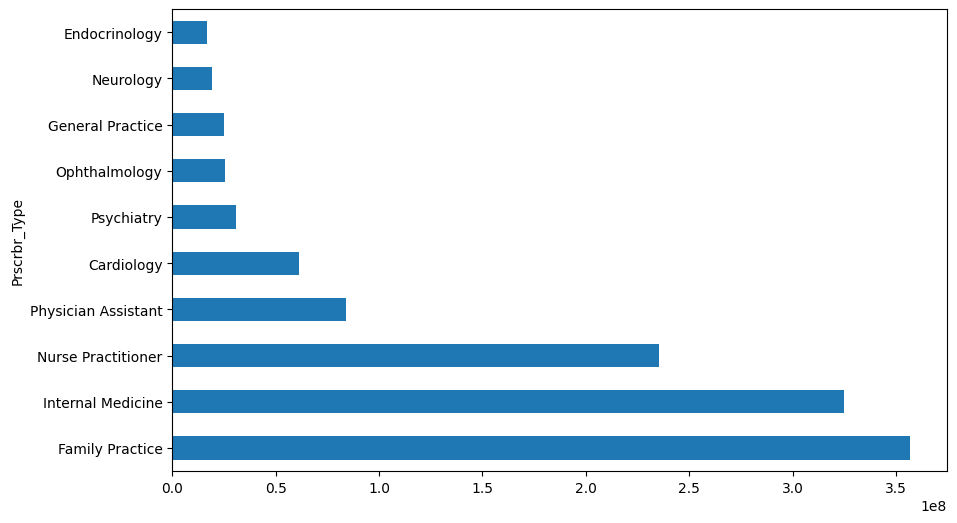

In [49]:
top_specialties.plot(kind='barh', figsize=(10,6))

Revenue generated by speciality of precriber

In [69]:
top_specialties_count = (
    df.groupby('Prscrbr_Type')['Tot_Drug_Cst']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_specialties_count

Prscrbr_Type
Internal Medicine      3.398838e+10
Nurse Practitioner     3.297548e+10
Family Practice        2.949658e+10
Hematology-Oncology    1.391991e+10
Cardiology             1.195811e+10
Physician Assistant    1.186239e+10
Endocrinology          8.727670e+09
Pulmonary Disease      7.908221e+09
Neurology              7.845843e+09
Rheumatology           7.790991e+09
Name: Tot_Drug_Cst, dtype: float64

<Axes: ylabel='Prscrbr_Type'>

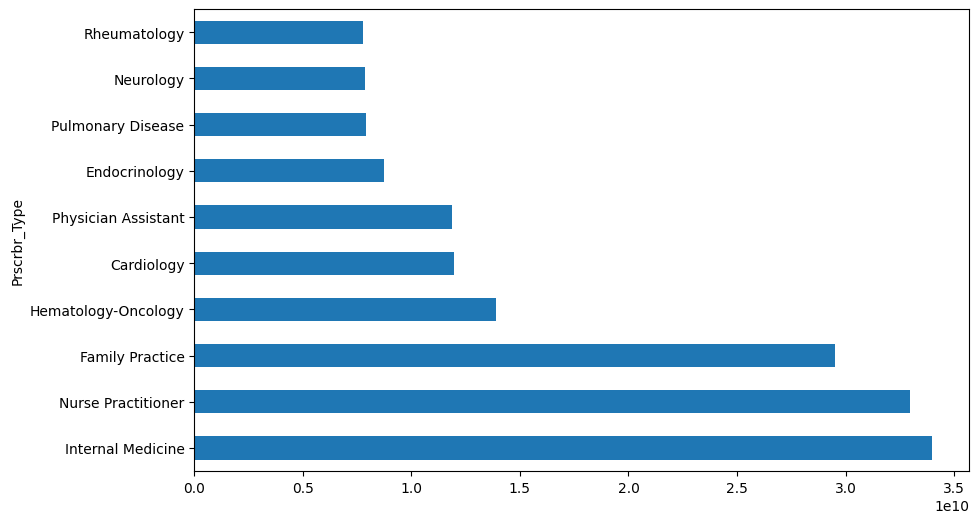

In [70]:
top_specialties_count.plot(kind='barh', figsize=(10,6))

Nurse practitioner(NP) is the top 3 prescribing the drugs. AS NPs are licensed, autonomous advanced practice registered nurses who provide comprehensive healthcare, including diagnosing and treating acute and chronic illnesses, ordering diagnostic tests, and prescribing medication. they are prescribing more the internal medicine but have less claims.

In [52]:
top_cities = (
    df.groupby('Prscrbr_City')['Tot_Clms']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cities

Prscrbr_City
New York        11546058
Brooklyn        10833057
Houston         10003136
Miami            9895892
Los Angeles      8361870
Chicago          8061152
Philadelphia     7478044
Springfield      6740700
San Antonio      6316642
Columbus         5889544
Name: Tot_Clms, dtype: int64

Number of prescriptions per city

<Axes: ylabel='Prscrbr_City'>

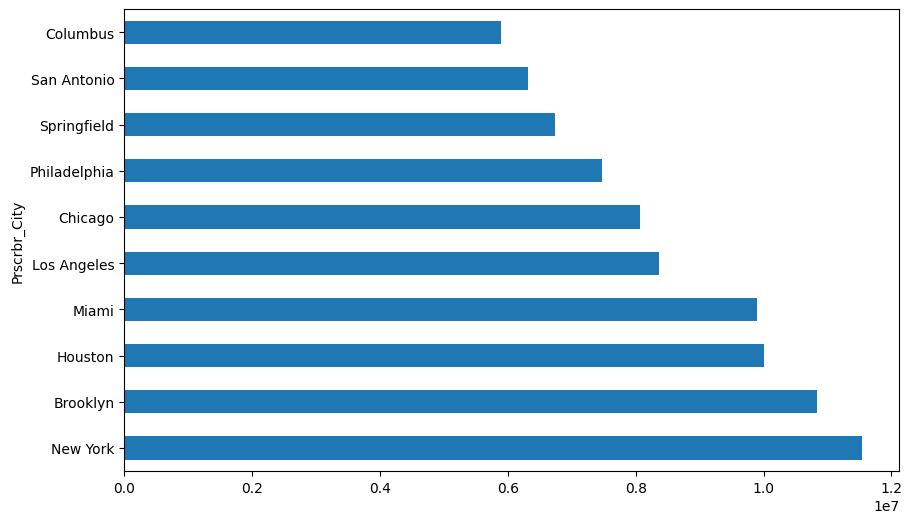

In [53]:
top_cities.plot(kind='barh', figsize=(10,6))

Revenue generated as per the city

<Axes: title={'center': 'Top 10 Cities by Total Drug Revenue'}, ylabel='Prscrbr_City'>

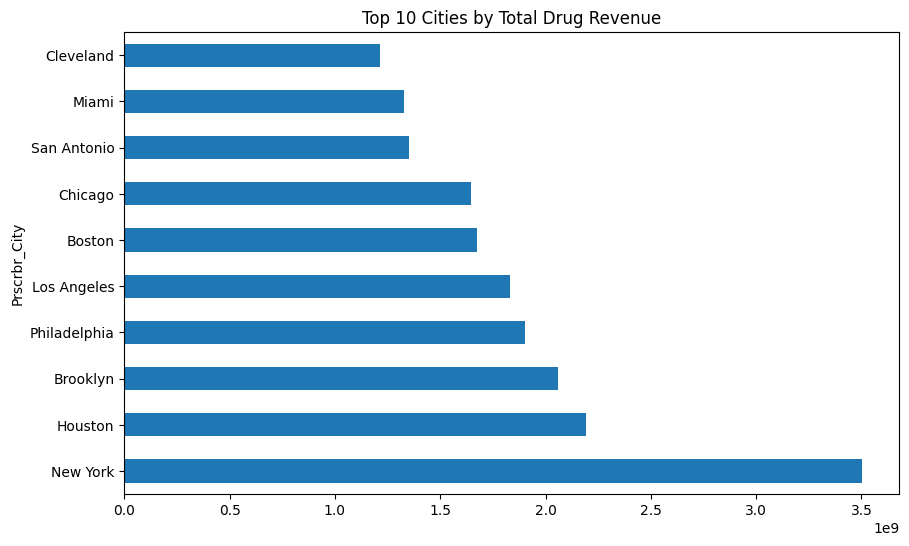

In [71]:
top_cities_revenue = (
    df.groupby('Prscrbr_City')['Tot_Drug_Cst']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cities_revenue.plot(kind='barh', figsize=(10,6), title="Top 10 Cities by Total Drug Revenue")

In [ ]:
drug_counts = df.groupby('Prscrbr_NPI')['Gnrc_Name'].nunique()

drug_counts.describe() 

count    1.104162e+06
mean     2.309854e+01
std      3.516490e+01
min      1.000000e+00
25%      3.000000e+00
50%      8.000000e+00
75%      2.700000e+01
max      5.310000e+02
Name: Gnrc_Name, dtype: float64

In [ ]:
drug_counts.head(10)

Prscrbr_NPI
1003000126     2
1003000142    21
1003000167     2
1003000423     2
1003000480     2
              ..
1992999437     4
1992999551    78
1992999650     3
1992999825     9
1992999874     2
Name: Gnrc_Name, Length: 1104162, dtype: int64

In [66]:
df['generic_match'] = df['Gnrc_Name'] == df['Mapped_Generic']

df['generic_match'].value_counts()

generic_match
True     15975866
False    10819012
Name: count, dtype: int64

Checking cost per claim for generic drugs

In [ ]:
df['cost_per_claim'] = df['Tot_Drug_Cst'] / df['Tot_Clms']

df['cost_per_claim'].groupby(df['generic_match']).mean().sort_values(ascending=False).head(10)

generic_match
True     236.337673
False    220.221316
Name: cost_per_claim, dtype: float64

In [79]:
top_costly_generics = df['cost_per_claim'].groupby(df['Gnrc_Name']).mean().sort_values(ascending=False).head(10)

top_costly_generics 

Gnrc_Name
elapegademase-lvlr               371538.777538
caplacizumab-yhdp                234659.415000
golodirsen                       186695.516667
metreleptin                      171098.476351
olipudase alfa-rpcp              138585.495000
vutrisiran sodium                121567.549584
c1 esterase inhibitor, recomb    117456.259513
carglumic acid                   116587.804167
galsulfase                       108672.650000
asfotase alfa                    100979.854290
Name: cost_per_claim, dtype: float64

<Axes: title={'center': 'Top 10 Costly Generic Drugs'}, ylabel='Gnrc_Name'>

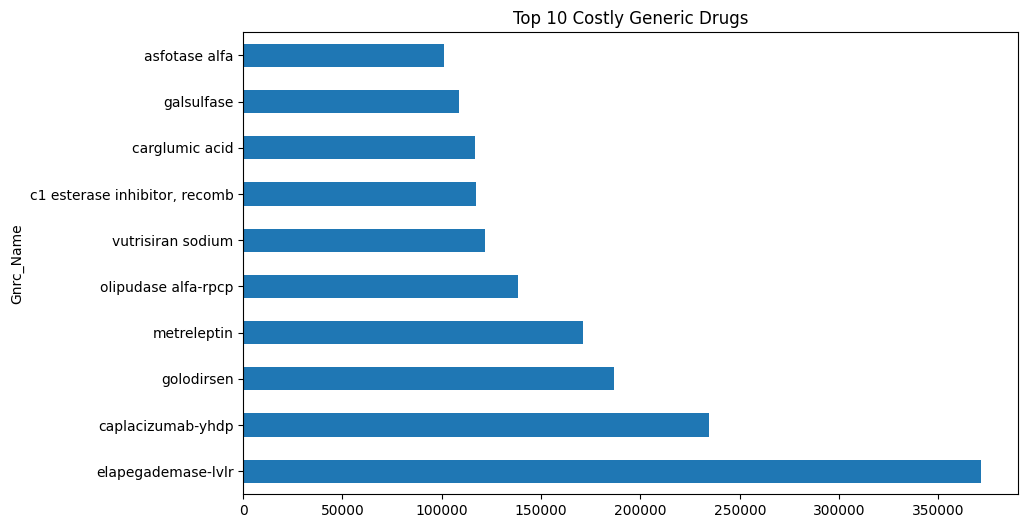

In [78]:
top_costly_generics.plot(kind='barh', figsize=(10,6), title="Top 10 Costly Generic Drugs")